In [3]:
from pathlib import Path
import iris
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="xarray")
import xarray as xr
import matplotlib.pyplot as plt
import os

# Regional Ancillary Suite workflow

A notebook to document and check the outputs of the Regional Ancillary Suite (RAS).

Here we breakdown the (complicated) ancillary workflow to help give insights when things go wrong.

The `rose/cylc` task graph for the RAS is quite complex (see below), but in this notebook we will step through each task separately and document its outputs.  This will help you understand the dependencies and help you trace any errors if they occur when you create new ancillaries for your own experiments

<img src="Graph.png" width="900">

The firsts tasks that run in this suite are `INSTALL_COLD`, `ANCIL_ANTS` and`ANCIL_ANTS`. These install a local version of the `ants` python module in your `~/cylc-run/RAS_minimum_working_example` directory, along with various global ancillary datasets required to genreate regional information.

Once these set-up tasks have been complete, the suite will begin to generate ancillaries for every designed region and resolution defined in the suite's `rose-suite.conf` file.

Our `rose-suite.conf` contains one region:
```
rg01_name="Lismore-tiny"
```
which contains two resolutions:
```
rg01_rs01_name="era5"
rg01_rs02_name="d1100"
```
You can see from the above image that the suite has generated a seperate task family for each resolution:
```
Lismore-tiny_era5_ancil
Lismore-tiny_d1100_ancil
```
Both task families contain and identical set of tasks. In this workbook we will step through the second task family, `Lismore-tiny_d1100_ancil`

### Step 1. Install the grid definition namelists.

Running the task `Lismore-tiny_d1100_ancil_top` installs the following files into `~cylc-run/RAS_minimum_working_example/share/data/ancils/Lismore-tiny/d1100`

- `grid.nl`
- `grid_eg.nl`
- `L70_80km`
- `vertlevs.nl`
  
The first two files are Fortran 'namelist' files that contain information of the horizontal latitute/longitude grid (i.e. its bounds, number of points and grid spacing). The latter two files provide the vertical information of the grid.

### Step 2. Generate the land-sea mask and vegetation ancillaries on the defined grid.

The `Lismore-tiny_d1100_ancil_lct` task generates the land-sea mask and vegetation ancillaries that are consistent with the grid definition contained in the grid namelist files.

This task generates the following files:

- `qrparm.mask_cci` (the land-sea binary mask in UM ancillary binary format)
- `qrparm.mask_cci.nc`(as above, but in netCDF format)
- `qrparm.landfrac` (the land fraction mask in UM ancillary binary format)
- `qrparm.landfrac.nc`(as above, but in netCDF format)
- `qrparm.mask_sea`(another land-sea binary mask using different coastline defintion in UM ancillary binary format - not used by the standard RAS suite)
- `qrparm.mask_sea.nc`(as above, but in netCDF format)
- `qrparm.veg.frac_cci_pre_c4` (9 level vegetation grids in UM ancillary binary format)
- `qrparm.veg.frac_cci_pre_c4.nc` (as above, but in netCDF format)

It also generates a symbolic link to `qrparm.mask` to point to`qrparm.mask_cci`. This is done to track providence of the mask generation (i.e. using CCI datasets).

Let's examine the binary land-sea mask and the vegetation grids.

In [5]:
home_dir=os.environ['HOME']
HOME=Path(home_dir)
ANCIL_DIR = Path( HOME / 'cylc-run/RAS_minimum_working_example/share/data/ancils/Lismore-tiny/d1100')

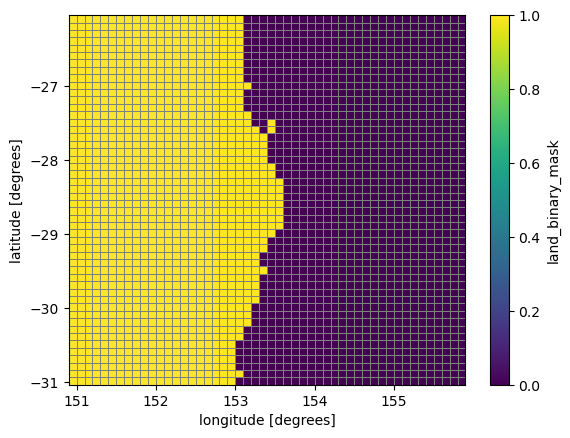

In [9]:
lsm, = iris.load( ANCIL_DIR / 'qrparm.mask')
xr.DataArray.from_iris(lsm).plot(edgecolor='grey',linewidth=0.5)

In [7]:
veg_frac_pre_c4, = iris.load( ANCIL_DIR / 'qrparm.veg.frac_cci_pre_c4')

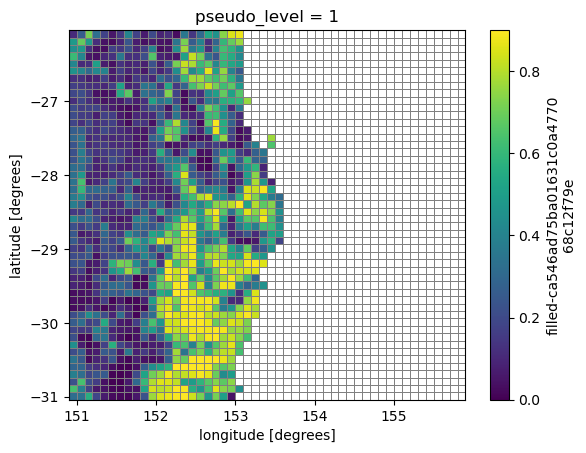

In [8]:
xr.DataArray.from_iris(veg_frac_pre_c4[0]).plot(edgecolor='grey',linewidth=0.5)

### Step 3. Include World Cover data (optional).

This task will run if you have set `WC_URBAN=True` in your `rose-suite.conf` file. 

If applicable, this tasks modifies the vegetation ancillaries to include the lastest 'World Cover' data. This step allows better representation of urban areas. This step uses the task `Lismore-tiny_d1100_ancil_lct_postproc_wc_urban` and will update the files:

- `qrparm.veg.frac_cci_pre_c4`, `qrparm.veg.frac_cci_pre_c4.nc`,

and generate the files
- `qrparm.veg.frac_cci_pre_c4_pre_wc`, `qrparm.veg.frac_cci_pre_c4_pre_wc.nc`

In [15]:
veg_frac_pre_c4_wc, = iris.load( ANCIL_DIR / 'qrparm.veg.frac_cci_pre_c4_pre_wc')

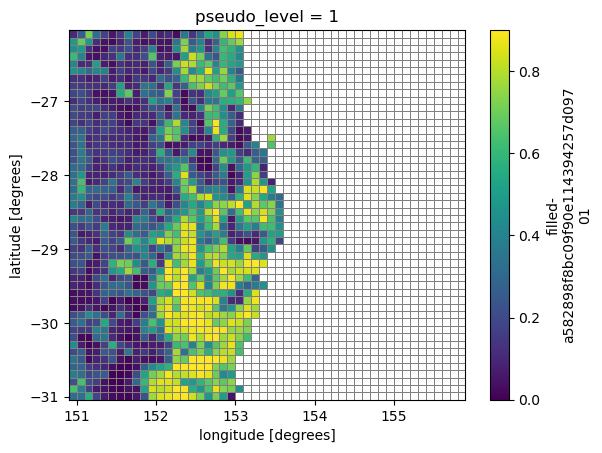

In [16]:
xr.DataArray.from_iris(veg_frac_pre_c4_wc[0]).plot(edgecolor='grey',linewidth=0.5)

### Step 4. Install C4 land cover data

The vegetation processing is completed with the task `Lismore-tiny_d1100_ancil_lct_postproc_c4`. This injects 'C4' data into the land cover type fraction dataset, and produces the output files:

- `qrparm.veg.frac_cci`, `qrparm.veg.frac_cci.nc`

A symbolic link is created to both of these files which removes the last suffix, i.e.

- `qrparm.veg.frac -> qrparm.veg.frac_cci`
- `qrparm.veg.frac.nc -> qrparm.veg.frac_cci.nc`

In [22]:
veg_frac, = iris.load( ANCIL_DIR / 'qrparm.veg.frac_cci')

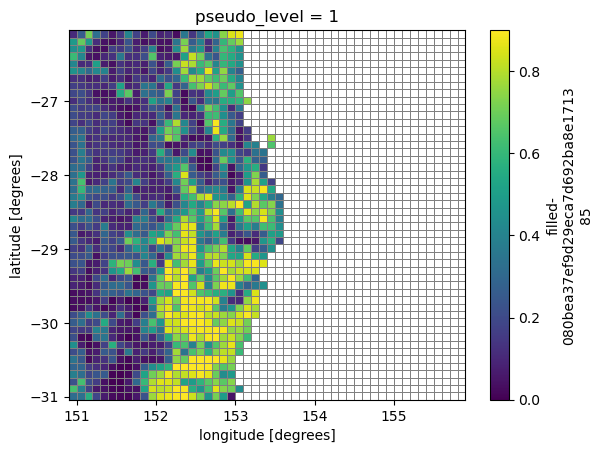

In [23]:
xr.DataArray.from_iris(veg_frac[0]).plot(edgecolor='grey',linewidth=0.5)

The following flowchart summarises the task flow to generate the vegetation land cover classification ancillaries.

<img src="ancil_lct_flow-2.png">

We have now run all the major master, 'umbrella' tasks for the ancilliary suite.

Now the final vegetation land cover classification ancillaries have been created, the suite splits and launches many tasks in parallel. Some tasks are grouped into their own subclasses with their own dependencies, such as

- orography
- soil characteristics
- leaf areas and canopy heights
- ice and snow
- moruses

Let's review the orography set of tasks first.

The first orography task is `Lismore-tiny_d1100_ancil_cap_orog`. Any tasks that contain `cap` in their task name do not use the python `ants` library. Rather they use the older UM binary. E.g. this task is launched with the command
```
$ more app/ancil_cap_orog/rose-app.conf 
meta=ancilOrog

[command]
default=rose mpi-launch -v central_ancillary.exe
```


### Step 5. Generate orography.

Triggering the task `Lismore-tiny_d1100_ancil_cap_orog` will generate the file `qrparm.orog`.

In [26]:
orog = iris.load( ANCIL_DIR / 'qrparm.orog')

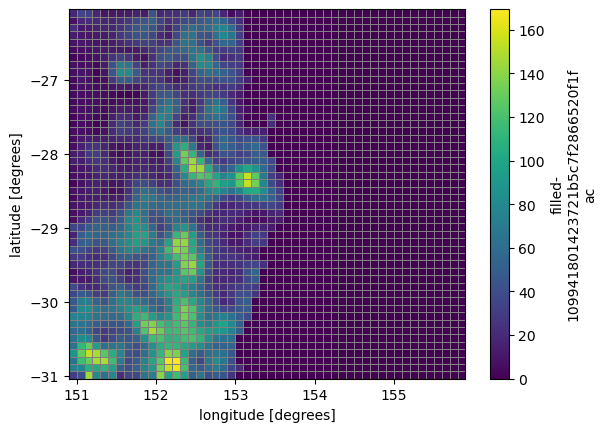

In [27]:
xr.DataArray.from_iris(orog[0]).plot(edgecolor='grey',linewidth=0.5)

The co-ordinates of `qrparm.orog` are produced by an older Fortan CAP exe and are 32-bit co-ordinates by default.

The next orography task is `Lismore-tiny_d1100_ancil_mean_orog`. This is two-step task that firstly
- produces a concatentated SRTM orography file `orog_srtm/SRTM_concat.nc` (which is a global dataset)
- then produces the file `orog_srtm/qrparm.orog.srtm.nc`


In [50]:
orog_srtm=iris.load_cube(ANCIL_DIR / 'orog_srtm/qrparm.orog.srtm.nc')

OSError: One or more of the files specified did not exist:
    * "/home/548/pag548/cylc-run/RAS_minimum_working_example/share/data/ancils/Lismore-tiny/d1100/orog_srtm/qrparm.orog.srtm.nc" didn't match any files

In [49]:
xr.DataArray.from_iris(orog_srtm).plot(edgecolor='grey',linewidth=0.5)

NameError: name 'orog_srtm' is not defined

The final orography task is `Lismore-tiny_d1100_ancil_mean_orog_smooth`, which smooths the SRTM data according to a variety of algorithms. This produces the folowing files in `./orog_srtm/`:
```
qrparm.orog.srtm.121x1
qrparm.orog.srtm.121x10
qrparm.orog.srtm.121x100
qrparm.orog.srtm.121x20
qrparm.orog.srtm.121x35
qrparm.orog.srtm.121x5
qrparm.orog.srtm.121x50
qrparm.orog.srtm.121x75
```
In the main ancilliary directory, a symbolic link `qrparm.orog.mn` links to `orog_srtm/qrparm.orog.srtm.121x1`

In [66]:
orog_smooth, = iris.load( ANCIL_DIR / 'qrparm.orog.mn')

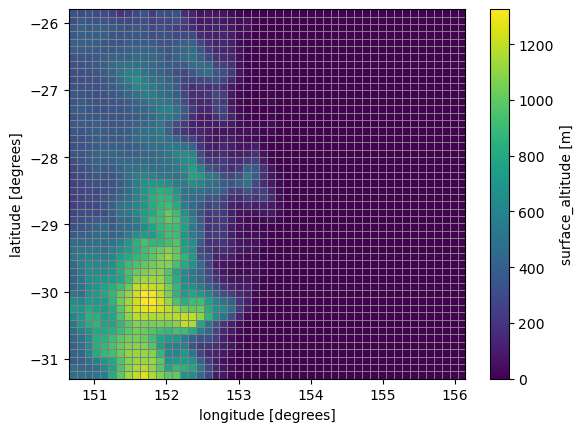

In [67]:
xr.DataArray.from_iris(orog_smooth).plot(edgecolor='grey',linewidth=0.5)

In [68]:
orog_smooth[0].coord('longitude').points

array([150.7    , 150.81   , 150.92   , 151.03   , 151.14   , 151.25   ,
       151.36   , 151.47   , 151.58   , 151.69   , 151.8    , 151.91   ,
       152.02   , 152.12999, 152.23999, 152.34999, 152.45999, 152.56999,
       152.68   , 152.79   , 152.9    , 153.01   , 153.12   , 153.23   ,
       153.34   , 153.45   , 153.56   , 153.67   , 153.78   , 153.89   ,
       154.     , 154.11   , 154.22   , 154.33   , 154.44   , 154.55   ,
       154.66   , 154.76999, 154.87999, 154.98999, 155.09999, 155.20999,
       155.31999, 155.43   , 155.54   , 155.65   , 155.76   , 155.87   ,
       155.98   , 156.09   ], dtype=float32)

The following flowchart describes the task flows for orography related tasks.

<img src="ancil_orog_flow.png">

## Step 7. Process soil characteristics

The next set of multi-step tasks are related to generating soil characteristics. First, we begin with `<Region>_<Resolution>_ancil_soils_hydr`. This reads in the global `soils_hydrology.nc` file, regrids it to our target domain and saves it to `soil_hydrology`

In [70]:
hydro = iris.load(ANCIL_DIR / 'soil_hydrology')

In [71]:
hydro[0].coords('latitude')[0].points

array([-31.24    , -31.13    , -31.02    , -30.91    , -30.8     ,
       -30.69    , -30.58    , -30.47    , -30.36    , -30.25    ,
       -30.14    , -30.029999, -29.92    , -29.81    , -29.7     ,
       -29.59    , -29.48    , -29.369999, -29.26    , -29.15    ,
       -29.039999, -28.93    , -28.82    , -28.71    , -28.6     ,
       -28.49    , -28.38    , -28.27    , -28.16    , -28.05    ,
       -27.94    , -27.83    , -27.72    , -27.61    , -27.5     ,
       -27.39    , -27.279999, -27.17    , -27.06    , -26.95    ,
       -26.84    , -26.73    , -26.619999, -26.51    , -26.4     ,
       -26.29    , -26.18    , -26.07    , -25.96    , -25.85    ],
      dtype=float32)

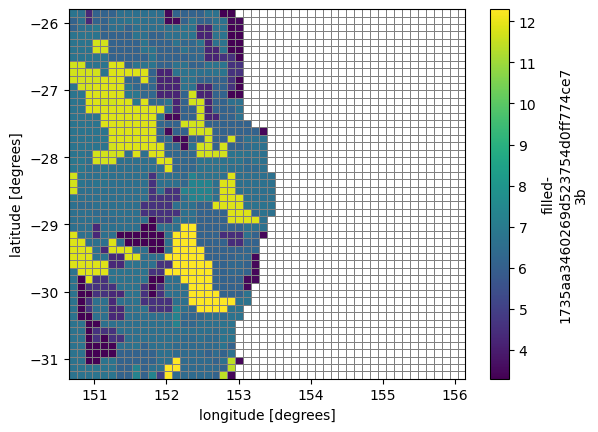

In [72]:
xr.DataArray.from_iris(hydro[0]).plot(edgecolor='grey',linewidth=0.5)

Next we process the soil albedo with the task `<Region>_<Resolution>_ancil_soil_albedo`. This reads in the global dataset `soil_albedo.nc` along with the existing files:
- `soil_hydrology`
- `qrparm.veg.frac.nc`
and outputs `qrparm.soil_cci`

The global albedo dataset may require manual inputs to provide data for small islands. It is defined on 0.05 degree grid.

In [73]:
albedo = xr.open_dataset('/home/548/pag548/cylc-run/rCM3-ancil-suite/share/data/etc/ancil_master_ants/soil_albedo/classic/v3/soil_albedo.nc')

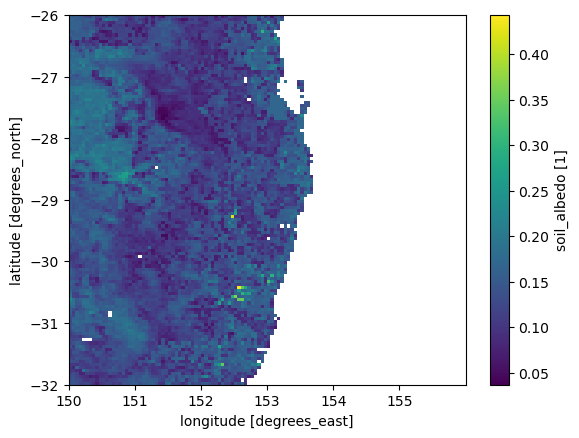

In [74]:
albedo.soil_albedo.sel(latitude=slice(-26,-32),longitude=slice(150,156)).plot()

In [78]:
soil = iris.load( ANCIL_DIR / 'qrparm.soil_cci')

In [79]:
soil[0].coords('latitude')[0].points

array([-31.23999977, -31.12999916, -31.02000046, -30.90999985,
       -30.79999924, -30.69000053, -30.57999992, -30.46999931,
       -30.36000061, -30.25      , -30.13999939, -30.02999878,
       -29.92000008, -29.80999947, -29.70000076, -29.59000015,
       -29.47999954, -29.36999893, -29.26000023, -29.14999962,
       -29.03999901, -28.93000031, -28.81999969, -28.70999908,
       -28.60000038, -28.48999977, -28.37999916, -28.27000046,
       -28.15999985, -28.04999924, -27.94000053, -27.82999992,
       -27.71999931, -27.61000061, -27.5       , -27.38999939,
       -27.27999878, -27.17000008, -27.05999947, -26.95000076,
       -26.84000015, -26.72999954, -26.61999893, -26.51000023,
       -26.39999962, -26.29000092, -26.18000031, -26.06999969,
       -25.95999908, -25.85000038], dtype='>f8')

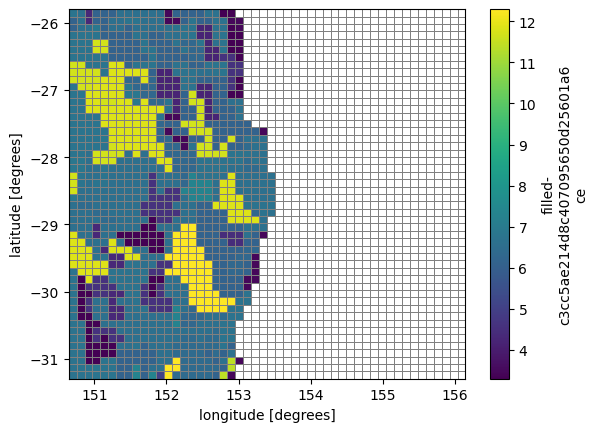

In [80]:
xr.DataArray.from_iris(soil[0]).plot(edgecolor='grey',linewidth=0.5)

The last task in this dependency is `<Region>_<Resolution>_ancil_soil_dust`. This processes the `qrparm.soil_cci` and `qrparm.veg.frac` ancillary files and generates the ancillary `qrparm.soil.dust`

In [81]:
dust = iris.load( ANCIL_DIR / 'qrparm.soil.dust')

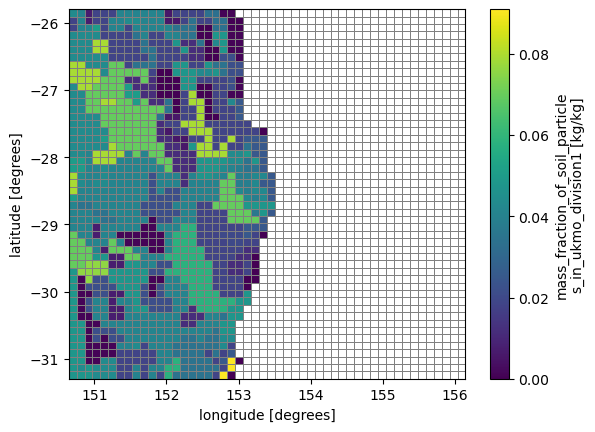

In [82]:
xr.DataArray.from_iris(dust[0]).plot(edgecolor='grey',linewidth=0.5)

The flowchart below describes the dependencies of the above soil-related tasks.

<img src="ancil_soil_flow.png">

There are two stand-alone soils tasks.

The first is`<Region>_<Resolution>_ancil_soil_roughness` which uses the existing `qrparm.veg.frac.nc` file along with global MODIS leaf area index data and global soil roughness data to produce `qrparm.soil_roughness`.

In [83]:
rough, = iris.load( ANCIL_DIR / 'qrparm.soil_roughness')

/home/548/pag548/.local/lib/python3.12/site-packages/iris/fileformats/_ff.py:737: _WarnComboLoadingDefaulting: The stash code m01s00i097 is on a grid 0 which has not been explicitly handled by the fieldsfile loader. Assuming the data is on a P grid.
  warnings.warn(


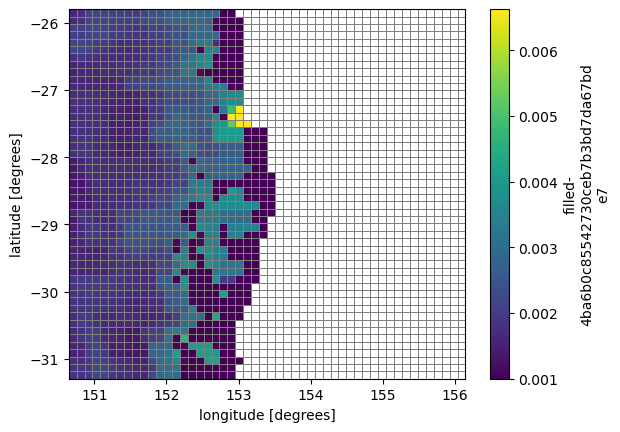

In [84]:
xr.DataArray.from_iris(rough).plot(edgecolor='grey',linewidth=0.5)

The second task is related to soil hydrology and is called`<Region>_<Resolution>_ancil_topographic_index`. It also uses `qrparm.veg.frac.nc` file along with global topographic wetness index data to produce `qrparm.hydtop`.

In [85]:
topo = iris.load( ANCIL_DIR / 'qrparm.hydtop')

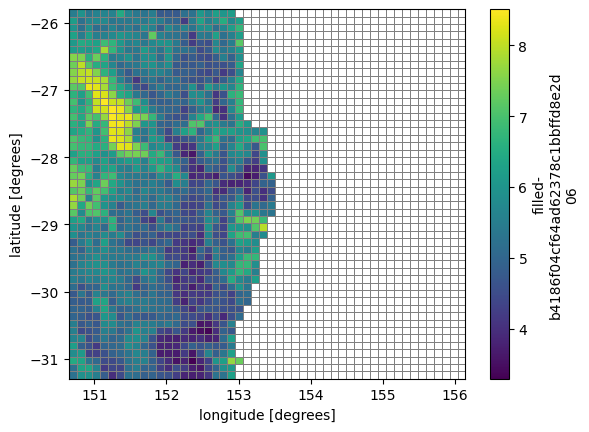

In [86]:
xr.DataArray.from_iris(topo[0]).plot(edgecolor='grey',linewidth=0.5)

## Step 8. Process leaf and canopy data.

We need to populate the vegetation with leaf and canopy data. The first task is `<Region>_<Resolution>_ancil_lai` which processes 'Leaf Area Index' and produces a temporary file `lai`.

In [30]:
lai, = iris.load( ANCIL_DIR / 'lai')

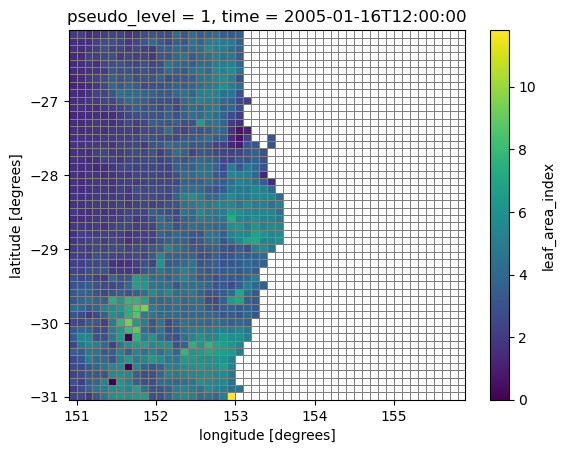

In [31]:
xr.DataArray.from_iris(lai)[0,0].plot(edgecolor='grey',linewidth=0.5)

The next task `<Region>_<Resolution>_ancil_canopy_heights` combines the `lai` ancillary with tree data and canopy height factors and writes the data to `qrparm.veg.func` 

In [32]:
lai_canopy = iris.load( ANCIL_DIR / 'qrparm.veg.func')

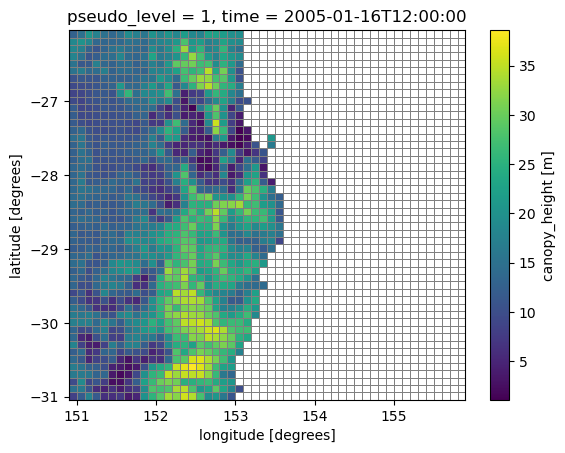

In [33]:
xr.DataArray.from_iris(lai_canopy[0][0,0]).plot(edgecolor='grey',linewidth=0.5)

Here is rose/cylc task graph with leaf and canopy tasks completed

<img src="graph-lai.png">

The flowchart below describes the dependencies of the above soil-related tasks.

<img src="ancil_lai_flow.png">

## Step 9. Process SST/ice and snow

The last multi-step tasks which contain a chain of dependencies begins with  `<Region>_<Resolution>_ancil_cap_vegfrac`. Like the previous `ancil_cap` task, this uses an older FORTRAN binary and is independent of the python-based `ants` workflow.

This task outputs
- `qrparm.veg.func_igbp`
- `qrparm.veg.frac_igbp`
- `qrparm.veg.dist`
- `qrparm.soil.dust_igbp`

And it updates `qrparm.soil`.

In [34]:
veg_frac_igbp, = iris.load( ANCIL_DIR / 'qrparm.veg.frac_igbp')

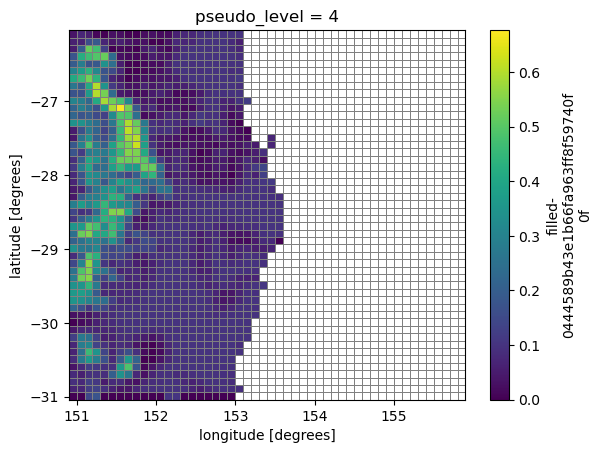

In [35]:
xr.DataArray.from_iris(veg_frac_igbp)[3].plot(edgecolor='grey',linewidth=0.5)

In [36]:
soil_dust = iris.load( ANCIL_DIR / 'qrparm.soil.dust_igbp')

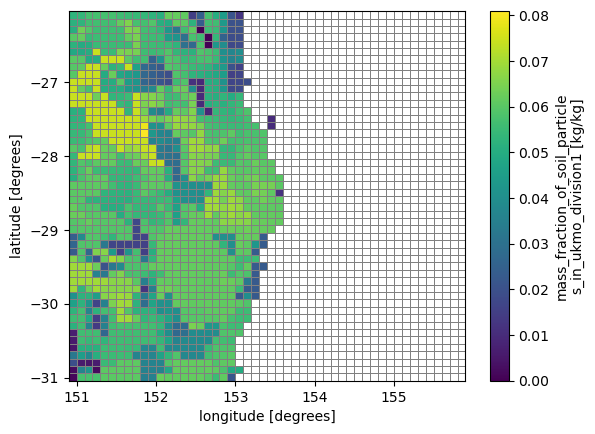

In [37]:
xr.DataArray.from_iris(soil_dust[0]).plot(edgecolor='grey',linewidth=0.5)

In [38]:
soil = iris.load( ANCIL_DIR / 'qrparm.soil')

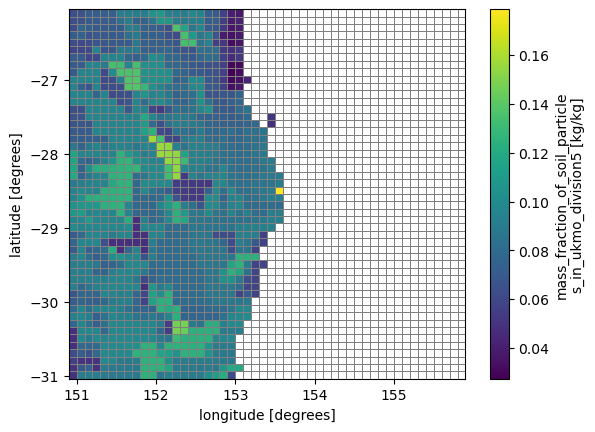

In [39]:
xr.DataArray.from_iris(soil_dust[4]).plot(edgecolor='grey',linewidth=0.5)

There are two tasks downstream of `<Region>_<Resolution>_ancil_cap_vegfrac`. One is `<Region>_<Resolution>_ancil_cap_sstice`. This task processes global climatologies for seaice and SSTs
- `qrclim.sst`
- `qrclim.seaice`

In [40]:
seaice = iris.load( ANCIL_DIR / 'qrclim.seaice')

/jobfs/177454678.gadi-pbs/ipykernel_752247/979677363.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(seaice[1][0]).plot(edgecolor='grey',linewidth=0.5)


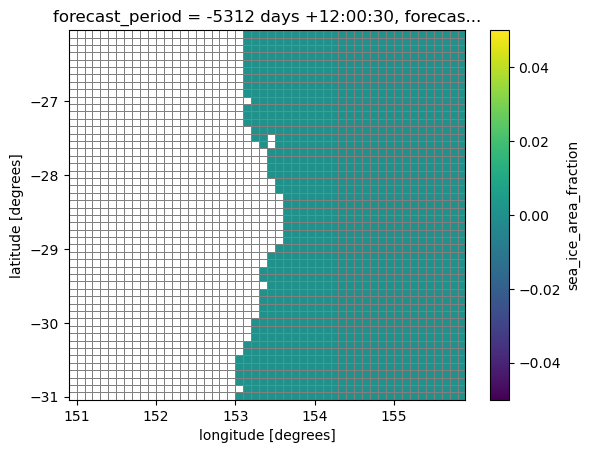

In [41]:
xr.DataArray.from_iris(seaice[1][0]).plot(edgecolor='grey',linewidth=0.5)

In [42]:
sst = iris.load( ANCIL_DIR / 'qrclim.sst')

/jobfs/177454678.gadi-pbs/ipykernel_752247/1747977962.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(sst[0][0]).plot(edgecolor='grey',linewidth=0.5)


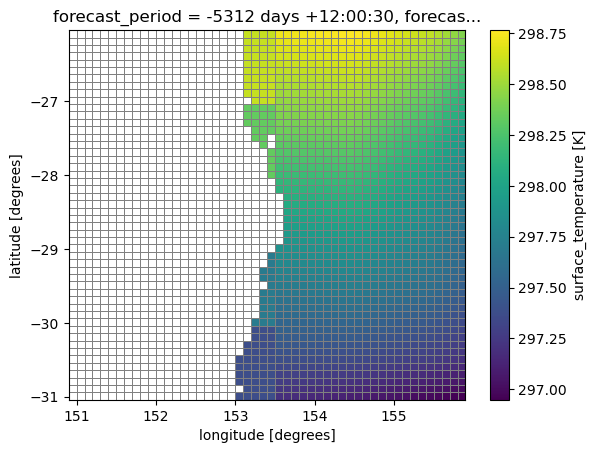

In [43]:
xr.DataArray.from_iris(sst[0][0]).plot(edgecolor='grey',linewidth=0.5)

The other task is `<Region>_<Resolution>_ancil_cap_smcsnow`. This task processes global climatologies for soil moisture content and snow. The output is `qrclim.smow`

In [44]:
smow = iris.load( ANCIL_DIR / 'qrclim.smow')

/home/548/pag548/.local/lib/python3.12/site-packages/iris/fileformats/pp.py:1490: CFWarning: this date/calendar/year zero convention is not supported by CF
  self._t1 = cftime.datetime(
/home/548/pag548/.local/lib/python3.12/site-packages/iris/fileformats/pp.py:1523: CFWarning: this date/calendar/year zero convention is not supported by CF
  self._t2 = cftime.datetime(


/jobfs/177454678.gadi-pbs/ipykernel_752247/217714727.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(smow[6][0]).plot(edgecolor='grey',linewidth=0.5)


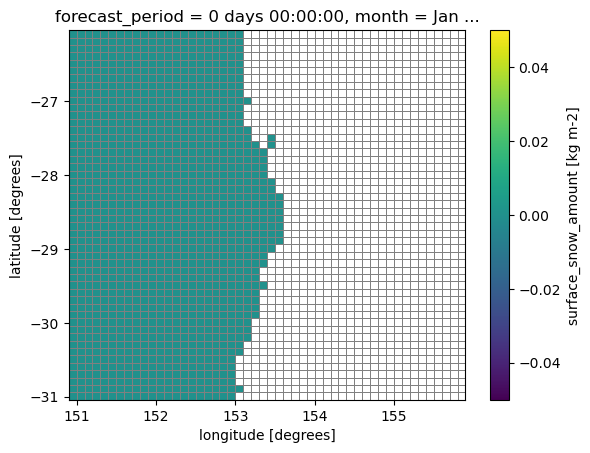

In [45]:
xr.DataArray.from_iris(smow[6][0]).plot(edgecolor='grey',linewidth=0.5)

The flowchart below shows the task dependencies for all `cap` related tasks.

## Step 10. Process remaining stand-alone tasks.

The last stand-alone tasks can be divided into three sections. The first is ozone processing:
- `<Region>_<Resolution>_ancil_cap_ozone`

which uses the FORTRAN exectuable. The next group of tasks compute aerosol climatologies as specified in the `suite.rc`
```
{% set AERO_CLIMS = ["biog", "biom", "blck", "dust", "ocff", "sslt", "sulp"] %}
```
- `<Region>_<Resolution>_ancil_ocff`
- `<Region>_<Resolution>_ancil_biog`
- `<Region>_<Resolution>_ancil_biom`
- `<Region>_<Resolution>_ancil_blck`
- `<Region>_<Resolution>_ancil_sslt`
- `<Region>_<Resolution>_ancil_sulp`
- `<Region>_<Resolution>_ancil_dust`

They simply regrid the global climatologies of these quantities onto the local lat/lon grid and the specified vertical levels. They output both UM ancillary format and netCDF files.

These are the remaining tasks that use the python `ants` workflows.
- `<Region>_<Resolution>_ancil_topographic_index`
- `<Region>_<Resolution>_ancil_clim_sea`
- `<Region>_<Resolution>_ancil_lake`

Let's examine the outputs of these tasks.

`<Region>_<Resolution>_ancil_cap_ozone` produces the local ozone climatology `qrclim.ozone.unfix`

In [96]:
ozone, = iris.load( ANCIL_DIR / 'qrclim.ozone.unfix')

/home/548/pag548/.local/lib/python3.12/site-packages/iris/fileformats/_ff.py:737: _WarnComboLoadingDefaulting: The stash code m01s00i060 is on a grid 22 which has not been explicitly handled by the fieldsfile loader. Assuming the data is on a P grid.
  warnings.warn(
/home/548/pag548/.local/lib/python3.12/site-packages/iris/fileformats/rules.py:376: IrisUserWarning: Unable to create instance of HybridPressureFactory. The source data contains no field(s) for 'surface_air_pressure'.
  warnings.warn(


/jobfs/177174656.gadi-pbs/ipykernel_1618406/2504981220.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(ozone[0]).plot(edgecolor='grey',linewidth=0.5)


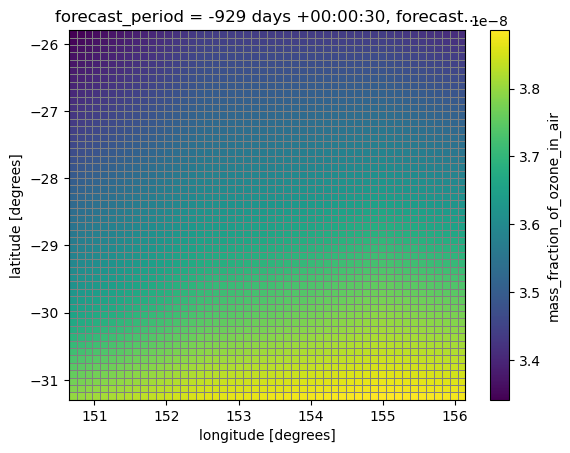

In [97]:
xr.DataArray.from_iris(ozone[0]).plot(edgecolor='grey',linewidth=0.5)

Let's now examine the aerosol climatologies:

- `<Region>_<Resolution>_ancil_ocff` produces dry aerosol climatologies of organic carbon from fossil fuels and is stored in `qrclim.ocff`.
- `<Region>_<Resolution>_ancil_sulp` produces dry aerosol climatologies of sulfate and is stored in `qrclim.sulp`.
- `<Region>_<Resolution>_ancil_biog` produces aerosol climatologies of biogenic Non-Methane Volatile Organic Compounds and is stored in `qrclim.biog`.
- `<Region>_<Resolution>_ancil_blk` produces aerosol climatologies of black carbon and are stored in `qrclim.blck`.
- `<Region>_<Resolution>_ancil_biom` produces aerosol climatologies of fresh burning biomass and is stored in `qrclim.biom`.
- `<Region>_<Resolution>_ancil_sslt` produces aerosol climatologies of sea salt particles and is stored in `qrclim.sslt`.
- `<Region>_<Resolution>_ancil_dust` produces aerosol climatologies of dust and is stored in `qrclim.dust`.

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/iris/fileformats/rules.py:371: IrisUserWarning: Unable to create instance of HybridHeightFactory. The source data contains no field(s) for 'orography'.
  warnings.warn(
/jobfs/172902492.gadi-pbs/ipykernel_3151241/2672610593.py:11: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(clim[0][0,0]).plot(ax=ax)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/pytho

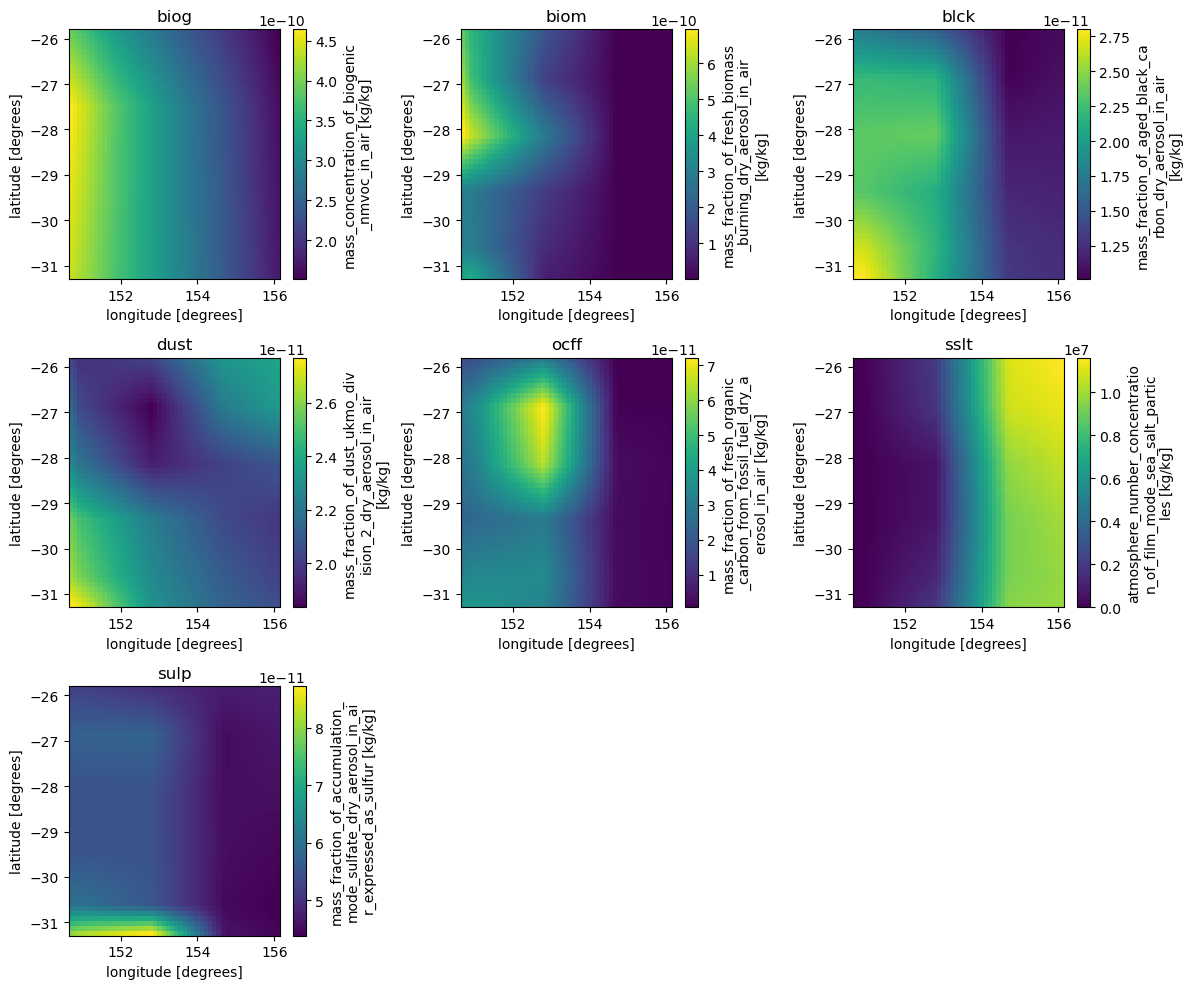

In [70]:
AERO_CLIMS = ["biog", "biom", "blck", "dust", "ocff", "sslt", "sulp"]

fig = plt.figure(figsize=(12,10))
num_rows=3
num_columns=3
Position=range(1,len(AERO_CLIMS)+1)
k=0
for CLIM in AERO_CLIMS:
    clim = iris.load( ANCIL_DIR / f'qrclim.{CLIM}')
    ax = fig.add_subplot(num_rows, num_columns, Position[k])
    xr.DataArray.from_iris(clim[0][0,0]).plot(ax=ax)
    ax.set_title(CLIM)
    k+=1
plt.tight_layout()

The remainings tasks are :
- `<Region>_<Resolution>_ancil_clim_sea` which produces climatology of ocean chlorophyll concentrations which are stored in `qrclim.sea`

In [71]:
sea, = iris.load( ANCIL_DIR / 'qrclim.sea')

/jobfs/172902492.gadi-pbs/ipykernel_3151241/3069948462.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(sea[0]).plot(edgecolor='grey',linewidth=0.5)


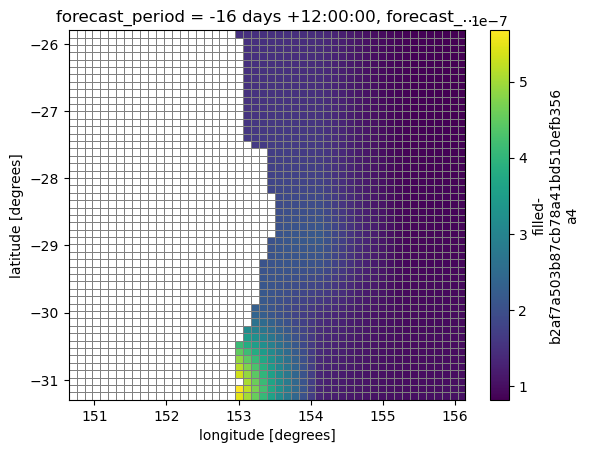

In [72]:
xr.DataArray.from_iris(sea[0]).plot(edgecolor='grey',linewidth=0.5)

- `<Region>_<Resolution>_ancil_lake` which regrids the global lake mask dataset and produces the local ancillary file `qrparm.lake`.  

In [7]:
global_lake_file = Path('/home/548/pag548/cylc-run/rCM3-ancil-suite/share/data/etc/ancil_master_ants//lake/ARClake/v2/qrdata.mask.nc')
global_lake = xr.load_dataset(global_lake_file)

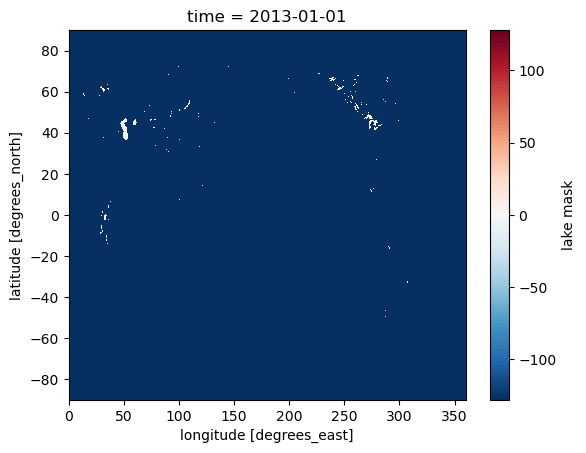

In [17]:
global_lake.lake_mask.plot()

In [2]:
lake, = iris.load( ANCIL_DIR / 'qrparm.lake')

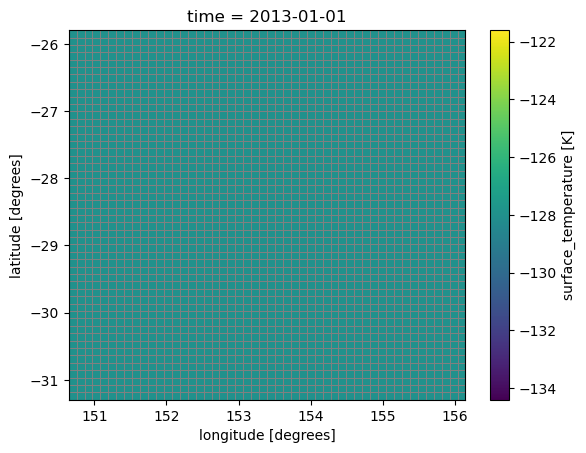

In [20]:
xr.DataArray.from_iris(lake).plot(edgecolor='grey',linewidth=0.5)

The global lake dataset identifies large inland lakes (e.g. Caspian Sea, The Great Lakes) and sets a mask value of -128 everywhere else

- `<Region>_<Resolution>_ancil_lct_postproc_moruses` performs a two-type urban fraction and urban morphology post-processor to implement the Met Office–Reading Urban Surface Exchange Scheme (MORUSES). The intermediate output file is `qrparm.MORUSES.morph`

In [21]:
moru = iris.load( ANCIL_DIR / 'qrparm.MORUSES.morph')

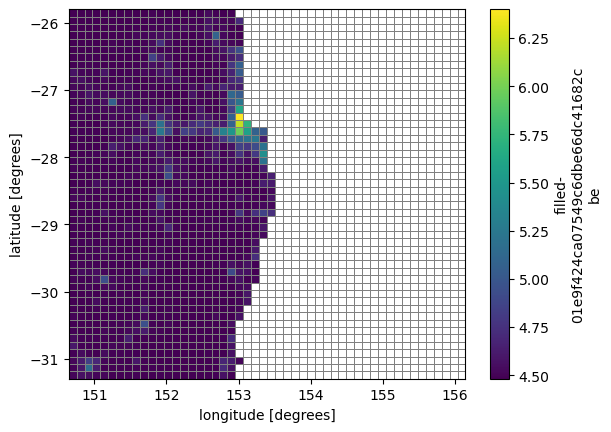

In [53]:
xr.DataArray.from_iris(moru[0]).plot(edgecolor='grey',linewidth=0.5)

- `<Region>_<Resolution>_ancil_lct_land` runs the application `app/ancil_snowfree_albedo/rose-app.conf`. The suite logic in `suite-runtime/ants.rc` states:
```
    [[{{ancil(regn, resln)}}_land]]
        # SW snow-free surface albedo.
        inherit = {{ancil(regn, resln)}},ANCIL_SNOWFREE_ALBEDO
```
and 
```
    [[ANCIL_SNOWFREE_ALBEDO]]
        inherit = ANCIL_ANTS, HOST_ANTS_MPP
        [[[environment]]]
            ROSE_TASK_APP=ancil_snowfree_albedo
```
The output of this task is `qrclim.land`

In [98]:
land = iris.load( ANCIL_DIR / 'qrclim.land')

/jobfs/177174656.gadi-pbs/ipykernel_1618406/2023900724.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(land[0][0]).plot(edgecolor='grey',linewidth=0.5)


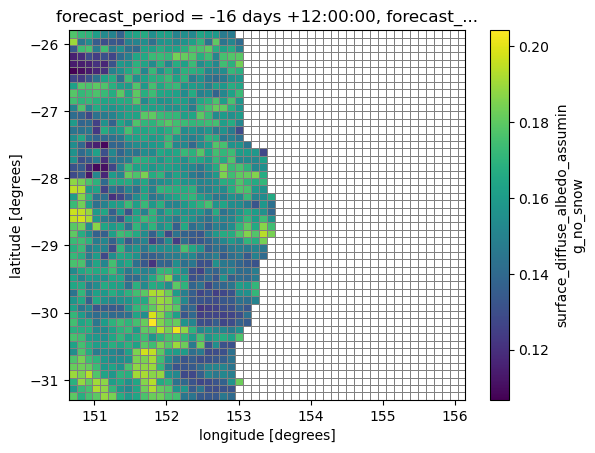

In [99]:
xr.DataArray.from_iris(land[0][0]).plot(edgecolor='grey',linewidth=0.5)

## How do I check the validity of the ancillaries?

Now run the notebook 'Check_UM_ancils.ipynb' to confirm:
- Your ancillaries generated with the python `ants` and Fortran `cap` workflows have the same co-ordinates (to within reasonable precision).
- There are no empty (or NaN values) over the land area defined by the land-sea mask